In [1]:
import pandas as pd

# Load the CSV portfolio
df = pd.read_csv("../data/insurance_portfolio.csv")

# Show the first 5 rows
df.head()

,policy_id,exposure,loss_prob,losses
0,1,21854.305348,0.117512,2568.153681
1,2,47782.143788,0.091337,4364.294797
2,3,37939.727382,0.106892,4055.471196
3,4,31939.631789,0.099842,3188.904072
4,5,12020.838820,0.024638,296.166949


In [2]:
# Show summary statistics for numeric columns
df.describe()

,policy_id,exposure,loss_prob,losses
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,27061.544899,0.092980,2528.305572
std,288.819436,13146.181288,0.058075,2158.007797
min,1.000000,5208.441035,0.001436,20.612564
25%,250.750000,15618.797041,0.048277,916.235223
50%,500.500000,27356.331945,0.081127,1921.730754
75%,750.250000,38494.381459,0.128242,3413.245841
max,1000.000000,49987.295298,0.372394,12105.233448


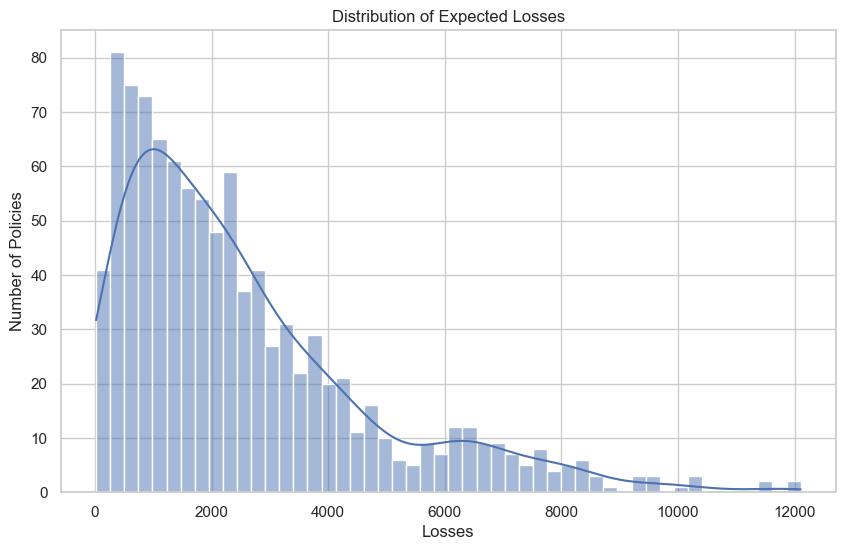

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Histogram of losses
plt.figure(figsize=(10,6))
sns.histplot(df['losses'], bins=50, kde=True)
plt.title("Distribution of Expected Losses")
plt.xlabel("Losses")
plt.ylabel("Number of Policies")
plt.show()

In [4]:
# Total Expected Loss
total_expected_loss = df['losses'].sum()
print("Total Expected Loss: ", total_expected_loss)

Total Expected Loss:  2528305.5721866335


In [5]:
# Value at Risk at 95% confidence
confidence_level = 0.95
var_95 = df['losses'].quantile(confidence_level)
print("95% Value at Risk (VaR): ", var_95)

95% Value at Risk (VaR):  7119.41836550985


In [6]:
# Conditional Value at Risk (Average loss beyond VaR)
cvar_95 = df[df['losses'] > var_95]['losses'].mean()
print("95% Conditional VaR (CVaR): ", cvar_95)

95% Conditional VaR (CVaR):  8572.655008455617


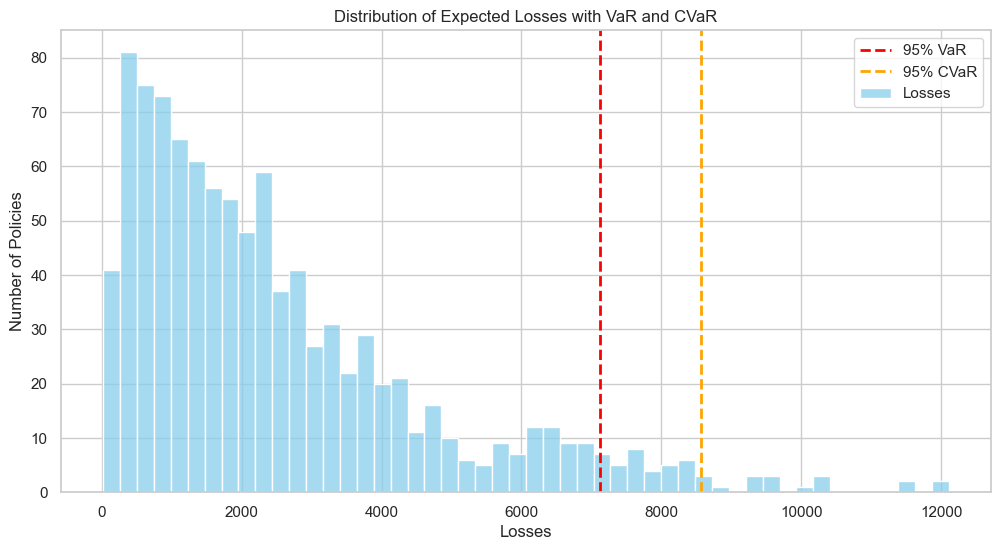

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style
sns.set(style="whitegrid")

# Create a figure
plt.figure(figsize=(12,6))

# Histogram of losses
sns.histplot(df['losses'], bins=50, kde=False, color='skyblue', label='Losses')

# Draw vertical lines for VaR and CVaR
plt.axvline(var_95, color='red', linestyle='--', linewidth=2, label='95% VaR')
plt.axvline(cvar_95, color='orange', linestyle='--', linewidth=2, label='95% CVaR')

# Titles and labels
plt.title("Distribution of Expected Losses with VaR and CVaR")
plt.xlabel("Losses")
plt.ylabel("Number of Policies")
plt.legend()
plt.show()

In [8]:
import numpy as np

# Number of simulations
n_simulations = 10000

# Array to store total losses for each simulation
simulated_total_losses = []

# Monte Carlo simulation
for _ in range(n_simulations):
    # For each policy, simulate a loss: either 0 or exposure, weighted by loss probability
    losses = np.random.binomial(1, df['loss_prob']) * df['exposure']
    total_loss = losses.sum()
    simulated_total_losses.append(total_loss)

# Convert to numpy array for easier analysis
simulated_total_losses = np.array(simulated_total_losses)

print("Monte Carlo simulation complete!")

Monte Carlo simulation complete!


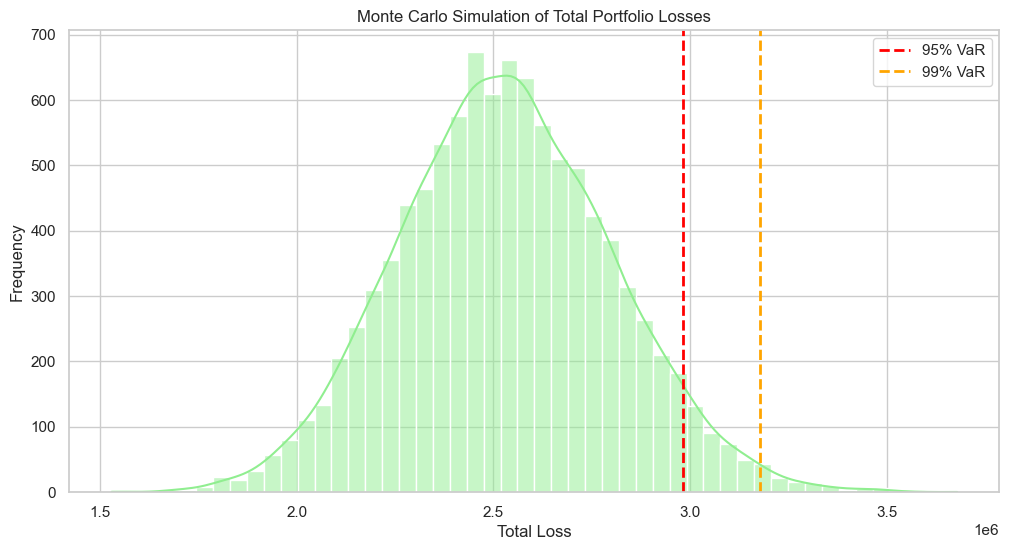

In [9]:
# Plot histogram of total simulated losses
plt.figure(figsize=(12,6))
sns.histplot(simulated_total_losses, bins=50, color='lightgreen', kde=True)
plt.title("Monte Carlo Simulation of Total Portfolio Losses")
plt.xlabel("Total Loss")
plt.ylabel("Frequency")
plt.axvline(np.percentile(simulated_total_losses, 95), color='red', linestyle='--', linewidth=2, label='95% VaR')
plt.axvline(np.percentile(simulated_total_losses, 99), color='orange', linestyle='--', linewidth=2, label='99% VaR')
plt.legend()
plt.show()

In [10]:
# Monte Carlo metrics
mc_var_95 = np.percentile(simulated_total_losses, 95)
mc_var_99 = np.percentile(simulated_total_losses, 99)
mc_mean = simulated_total_losses.mean()

print("Monte Carlo 95% VaR:", mc_var_95)
print("Monte Carlo 99% VaR:", mc_var_99)
print("Monte Carlo mean total loss:", mc_mean)

Monte Carlo 95% VaR: 2981595.7499830057
Monte Carlo 99% VaR: 3177618.8766087643
Monte Carlo mean total loss: 2529849.399958795


In [11]:
# Create a summary dictionary
summary = {
    "Total Expected Loss": [total_expected_loss],
    "Analytical 95% VaR": [var_95],
    "Analytical 95% CVaR": [cvar_95],
    "Monte Carlo Mean Loss": [mc_mean],
    "Monte Carlo 95% VaR": [mc_var_95],
    "Monte Carlo 99% VaR": [mc_var_99]
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary)

# Show the summary
summary_df

,Total Expected Loss,Analytical 95% VaR,Analytical 95% CVaR,Monte Carlo Mean Loss,Monte Carlo 95% VaR,Monte Carlo 99% VaR
0,2.528306e+06,7119.418366,8572.655008,2.529849e+06,2.981596e+06,3.177619e+06


In [12]:
# Save summary to CSV
summary_df.to_csv("../data/insurance_portfolio_summary.csv", index=False)
print("Summary saved to data/insurance_portfolio_summary.csv")

Summary saved to data/insurance_portfolio_summary.csv


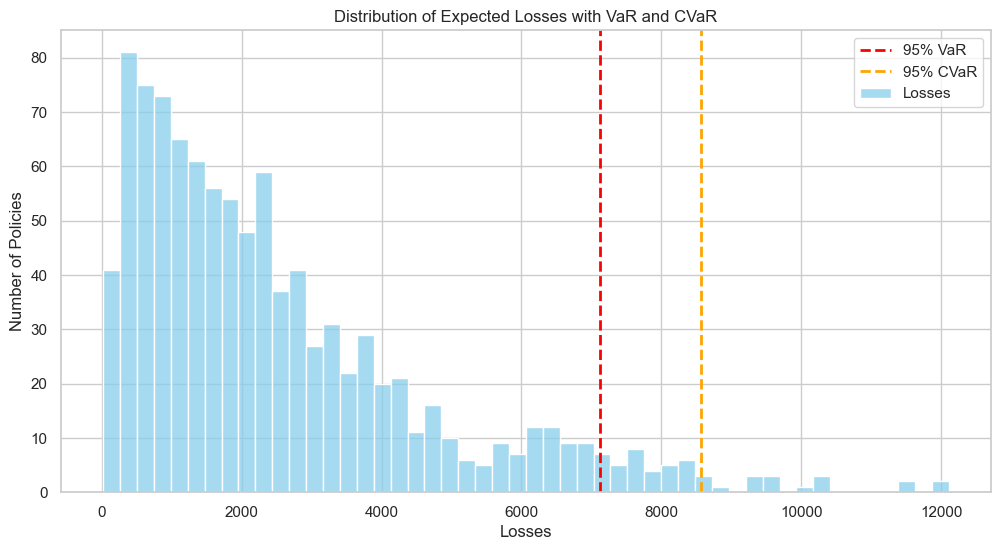

In [13]:
plt.figure(figsize=(12,6))
sns.histplot(df['losses'], bins=50, kde=False, color='skyblue', label='Losses')
plt.axvline(var_95, color='red', linestyle='--', linewidth=2, label='95% VaR')
plt.axvline(cvar_95, color='orange', linestyle='--', linewidth=2, label='95% CVaR')
plt.title("Distribution of Expected Losses with VaR and CVaR")
plt.xlabel("Losses")
plt.ylabel("Number of Policies")
plt.legend()
plt.savefig("../data/loss_distribution.png")  # Save as PNG
plt.show()

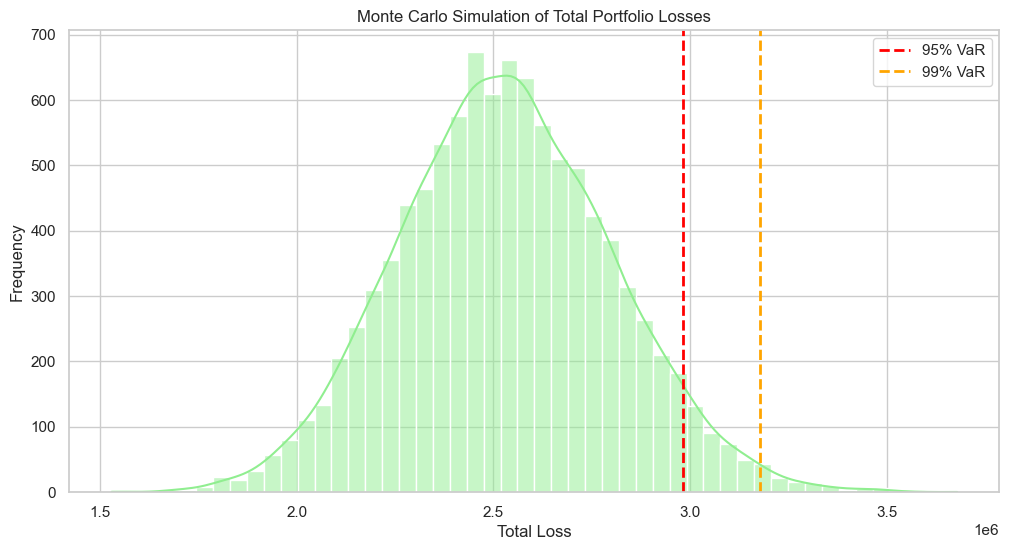

In [14]:
plt.figure(figsize=(12,6))
sns.histplot(simulated_total_losses, bins=50, color='lightgreen', kde=True)
plt.axvline(np.percentile(simulated_total_losses, 95), color='red', linestyle='--', linewidth=2, label='95% VaR')
plt.axvline(np.percentile(simulated_total_losses, 99), color='orange', linestyle='--', linewidth=2, label='99% VaR')
plt.title("Monte Carlo Simulation of Total Portfolio Losses")
plt.xlabel("Total Loss")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("../data/monte_carlo_losses.png")
plt.show()